In [3]:
import random
import time
import statistics
import heapq
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Selection Sort
def selection_sort(v):
    trocas = 0
    n = len(v)

    for i in range(n):
        menor = i

        for j in range(i + 1, n):

            if v[j] < v[menor]:
                menor = j

        if menor != i:
            v[i], v[menor] = v[menor], v[i]
            trocas += 1

    return trocas

# Merge Sort
def merge_sort(v):
    movimentacoes = [0]

    def merge(esq, dir):
        resultado = []
        i = 0
        j = 0

        while i < len(esq) and j < len(dir):

            if esq[i] <= dir[j]:
                resultado.append(esq[i])
                i += 1
            else:
                resultado.append(dir[j])
                j += 1

            movimentacoes[0] += 1

        resultado.extend(esq[i:])
        resultado.extend(dir[j:])

        movimentacoes[0] += len(esq[i:])
        movimentacoes[0] += len(dir[j:])

        return resultado

    def merge_rec(arr):

        if len(arr) <= 1:
            return arr

        meio = len(arr) // 2

        esquerda = merge_rec(arr[:meio])
        direita = merge_rec(arr[meio:])

        return merge(esquerda, direita)

    merge_rec(v)

    return movimentacoes[0]

# Heap Sort
def heap_sort(v):
    movimentacoes = 0
    heap = v.copy()
    heapq.heapify(heap)

    while heap:
        heapq.heappop(heap)
        movimentacoes += 1

    return movimentacoes

In [5]:
def executar_teste(nome, funcao, vetor):
    tempos = []
    operacoes = []

    for _ in range(3):
        copia = vetor.copy()
        inicio = time.perf_counter()
        op = funcao(copia)
        fim = time.perf_counter()

        tempos.append(fim - inicio)
        operacoes.append(op)

    return {
        "Algoritmo": nome,
        "Execução 1": tempos[0],
        "Execução 2": tempos[1],
        "Execução 3": tempos[2],
        "Tempo Médio": statistics.mean(tempos),
        "Desvio Padrão": statistics.stdev(tempos),
        "Operações": int(statistics.mean(operacoes))
    }

In [6]:
random.seed(42)

vetor_1000 = [random.randint(1, 100000) for _ in range(1000)]
vetor_10000 = [random.randint(1, 100000) for _ in range(10000)]
vetor_100000 = [random.randint(1, 100000) for _ in range(100000)]

In [7]:
resultados = []

tamanhos = [
    vetor_1000,
    vetor_10000,
    vetor_100000
]

for vetor in tamanhos:
    n = len(vetor)
    print(f"\nExecutando para {n} elementos")

    # Selection
    if n == 100000:

        resultados.append({
            "Algoritmo": "Selection Sort",
            "Tamanho": n,
            "Execução 1": "Interrompido",
            "Execução 2": "Interrompido",
            "Execução 3": "Interrompido",
            "Tempo Médio": "Interrompido",
            "Desvio Padrão": "-",
            "Operações": "-"
        })

    else:
        r = executar_teste(
            "Selection Sort",
            selection_sort,
            vetor
        )

        r["Tamanho"] = n
        resultados.append(r)

    # Merge
    r = executar_teste(
        "Merge Sort",
        merge_sort,
        vetor
    )

    r["Tamanho"] = n
    resultados.append(r)

    # Heap
    r = executar_teste(
        "Heap Sort",
        heap_sort,
        vetor
    )

    r["Tamanho"] = n
    resultados.append(r)

df = pd.DataFrame(resultados)
display(df)


Executando para 1000 elementos

Executando para 10000 elementos

Executando para 100000 elementos


,Algoritmo,Execução 1,Execução 2,Execução 3,Tempo Médio,Desvio Padrão,Operações,Tamanho
0,Selection Sort,0.025832,0.025167,0.022609,0.024536,0.001702,990,1000
1,Merge Sort,0.002758,0.00253,0.002473,0.002587,0.000151,9976,1000
2,Heap Sort,0.000286,0.000286,0.000283,0.000285,0.000002,1000,1000
3,Selection Sort,2.393485,2.387892,2.781083,2.52082,0.225412,9988,10000
4,Merge Sort,0.034806,0.034585,0.033527,0.034306,0.000683,133616,10000
5,Heap Sort,0.004,0.003873,0.003936,0.003936,0.000063,10000,10000
6,Selection Sort,Interrompido,Interrompido,Interrompido,Interrompido,-,-,100000
7,Merge Sort,0.527153,0.849265,0.837577,0.737999,0.182691,1668928,100000
8,Heap Sort,0.134351,0.131086,0.137495,0.134311,0.003205,100000,100000


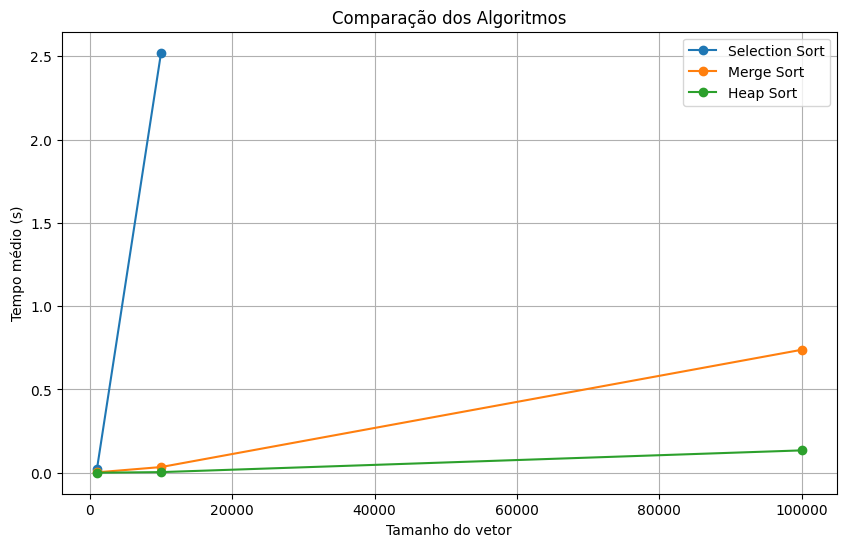

In [8]:
dados = df[df["Tempo Médio"] != "Interrompido"]

plt.figure(figsize=(10,6))

for algoritmo in dados["Algoritmo"].unique():
    sub = dados[dados["Algoritmo"] == algoritmo]

    plt.plot(
        sub["Tamanho"],
        sub["Tempo Médio"],
        marker="o",
        label=algoritmo
    )

plt.title("Comparação dos Algoritmos")
plt.xlabel("Tamanho do vetor")
plt.ylabel("Tempo médio (s)")
plt.legend()
plt.grid()

plt.show()